# Lab 9: Image Augmentation Practice

**Course:** Machine Learning Lab  
**Topic:** Practicing image augmentation with Keras `ImageDataGenerator`

## Lab Objective
The objective of this lab is to observe how different augmentation settings change training images and help improve model generalization.


## 1. Demonstrate Multiple Augmentations
This first section creates an augmentation generator and displays transformed versions of an image. The purpose is to visually understand how augmentation increases image variety.


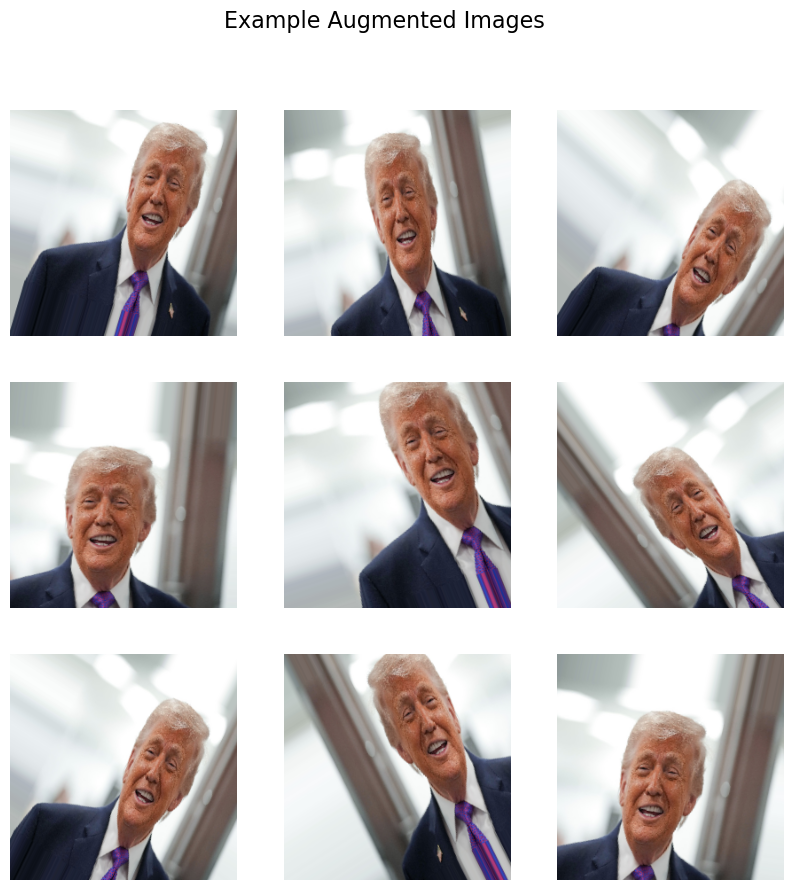

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
import matplotlib.pyplot as plt
import numpy as np

# Same augmentation settings as your train_datagen
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Load one sample image
img_path = r"C:\Sohaib ur Rahman Farooqi\University\8th Semester\Machine Learning\ML Lab\trump.jpeg"   
img = load_img(img_path, target_size=(256, 256))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Generate augmented images
plt.figure(figsize=(10, 10))

i = 1
for batch in datagen.flow(img_array, batch_size=1):
    plt.subplot(3, 3, i)
    plt.imshow(batch[0])
    plt.axis("off")
    i += 1
    if i > 9:  # Show 9 augmented images
        break

plt.suptitle("Example Augmented Images", fontsize=16)
plt.show()

# Practice


## 2. Import CNN and Augmentation Libraries
These libraries are needed for model creation, image loading, augmentation, checkpoint saving, plotting, and evaluation.


In [4]:
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns
import os

## 3. Set Checkpoint and Dataset Paths
The checkpoint path stores model weights, and the dataset paths identify the train, validation, and test folders used in the augmentation practice.


In [ ]:
checkpoints = r'C:\Sohaib ur Rahman Farooqi\University\8th Semester\Machine Learning\ML Lab\lab13\\E1-cp-{epoch:04d}-loss{val_loss:.2f}.h5'

In [11]:
train_dir = r'C:\Sohaib ur Rahman Farooqi\University\8th Semester\Machine Learning\ML Lab\LABNO7\train'
validation_dir = r'C:\Sohaib ur Rahman Farooqi\University\8th Semester\Machine Learning\ML Lab\LABNO7\validation'
test_dir = r'C:\Sohaib ur Rahman Farooqi\University\8th Semester\Machine Learning\ML Lab\LABNO7\test'
train_Cercospora_dir = os.path.join(train_dir, 'common_rust')

## 4. Define Augmentation Settings
This cell defines a set of possible augmentation transformations such as rotation, shifting, shearing, zooming, and flipping.


In [12]:
datagen = ImageDataGenerator(
                            rotation_range=40,
                            width_shift_range=0,
                            height_shift_range=0,
                            shear_range=0,
                            zoom_range=0,
                            horizontal_flip=True,
                            fill_mode='nearest')

## 5. Width Shift Augmentation
Width shifting moves the image horizontally. This helps the model learn that an object can appear in different horizontal positions.


In [13]:
datagen = ImageDataGenerator(
                             width_shift_range=0.2)

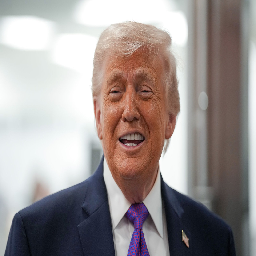

In [14]:
img

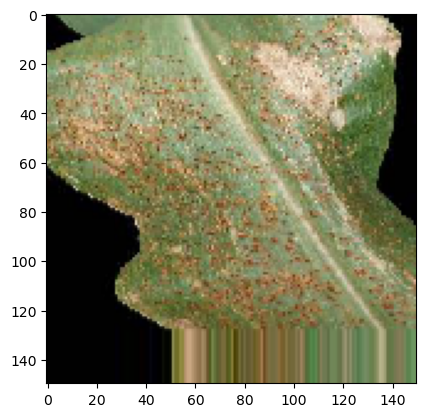

In [15]:
from tensorflow.keras.preprocessing import image
fnames = [os.path.join(train_Cercospora_dir, fname) for fname in os.listdir(train_Cercospora_dir)]
img_path = fnames[3]
img = image.load_img(img_path, target_size=(150, 150))
x = image.img_to_array(img)
x = x.reshape((1,) + x.shape)
i=0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(image.array_to_img(batch[0]))
    i += 1
    if i % 1== 0:
        break
plt.show()

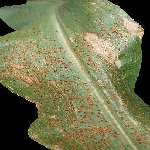

In [16]:
img

## 6. Stronger Width Shift
This section increases horizontal movement to show a stronger augmentation effect on the same type of transformation.


In [17]:
datagen = ImageDataGenerator(
                            rotation_range=0,
                            width_shift_range=0.5,
                            height_shift_range=0,
                            shear_range=0,
                            zoom_range=0,
                            horizontal_flip=True,
                            fill_mode='nearest')

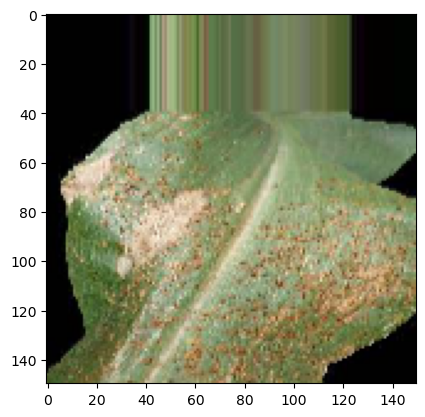

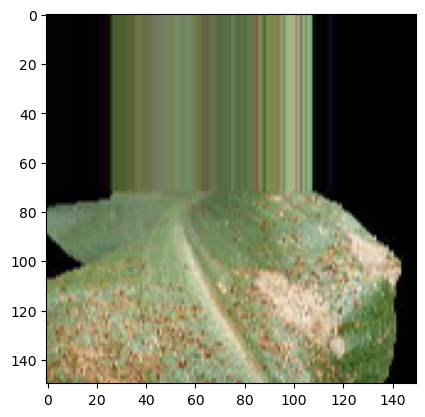

In [18]:
from tensorflow.keras.preprocessing import image
fnames = [os.path.join(train_Cercospora_dir, fname) for fname in os.listdir(train_Cercospora_dir)]
img_path = fnames[3]
img = image.load_img(img_path, target_size=(150, 150))
x = image.img_to_array(img)
x = x.reshape((1,) + x.shape)
i=0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(image.array_to_img(batch[0]))
    i += 1
    if i % 2== 0:
        break
plt.show()

## 7. Height Shift Augmentation
Height shifting moves the image vertically. This teaches the model to handle objects appearing at different vertical positions.


In [19]:
datagen = ImageDataGenerator(
                            rotation_range=0,
                            width_shift_range=0,
                            height_shift_range=0.5,
                            shear_range=0,
                            zoom_range=0,
                            horizontal_flip=True,
                            fill_mode='nearest')

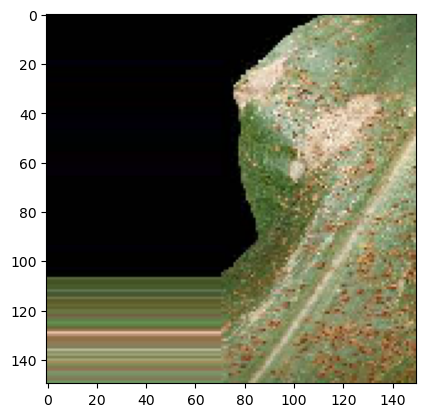

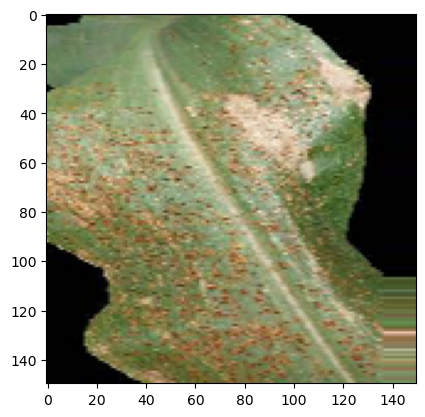

In [20]:
from tensorflow.keras.preprocessing import image
fnames = [os.path.join(train_Cercospora_dir, fname) for fname in os.listdir(train_Cercospora_dir)]
img_path = fnames[3]
img = image.load_img(img_path, target_size=(150, 150))
x = image.img_to_array(img)
x = x.reshape((1,) + x.shape)
i=0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(image.array_to_img(batch[0]))
    i += 1
    if i % 2== 0:
        break
plt.show()

## 8. Zoom Augmentation
Zoom augmentation changes the image scale. It helps the model become less sensitive to the size of the object in the image.


In [21]:
datagen = ImageDataGenerator(
                            rotation_range=0,
                            width_shift_range=0,
                            height_shift_range=0,
                            shear_range=0,
                            zoom_range=0.5,
                            horizontal_flip=True,
                            fill_mode='nearest')

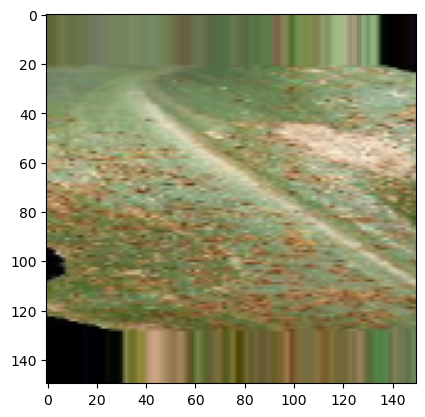

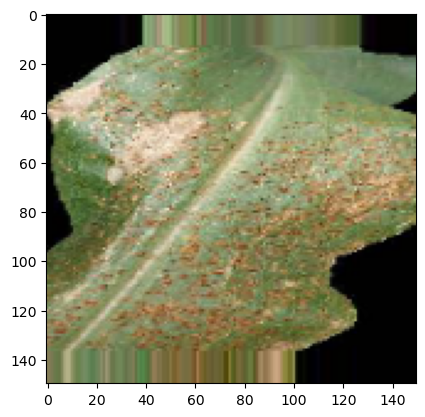

In [22]:
from tensorflow.keras.preprocessing import image
fnames = [os.path.join(train_Cercospora_dir, fname) for fname in os.listdir(train_Cercospora_dir)]
img_path = fnames[3]
img = image.load_img(img_path, target_size=(150, 150))
x = image.img_to_array(img)
x = x.reshape((1,) + x.shape)
i=0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(image.array_to_img(batch[0]))
    i += 1
    if i % 2== 0:
        break
plt.show()

## 9. Shear Augmentation
Shear augmentation slants the image. It creates geometric variation while keeping the class label the same.


In [23]:
datagen = ImageDataGenerator(
                            rotation_range=0,
                            width_shift_range=0,
                            height_shift_range=0,
                            shear_range=0.5,
                            zoom_range=0,
                            horizontal_flip=True,
                            fill_mode='nearest')

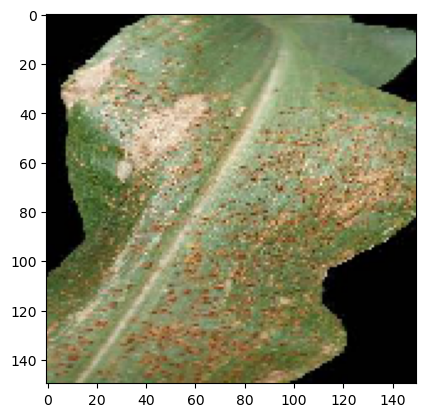

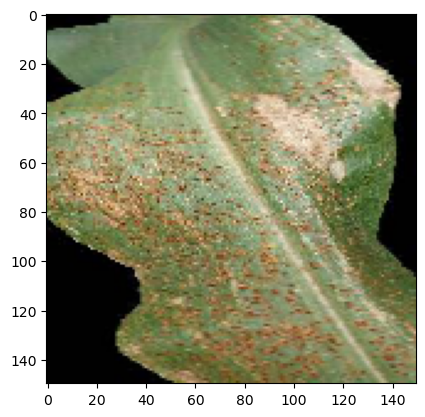

In [24]:
from tensorflow.keras.preprocessing import image
fnames = [os.path.join(train_Cercospora_dir, fname) for fname in os.listdir(train_Cercospora_dir)]
img_path = fnames[3]
img = image.load_img(img_path, target_size=(150, 150))
x = image.img_to_array(img)
x = x.reshape((1,) + x.shape)
i=0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(image.array_to_img(batch[0]))
    i += 1
    if i % 2== 0:
        break
plt.show()


## Conclusion
Image augmentation is useful for CNN training because it exposes the model to realistic variations in position, size, orientation, and shape. This can reduce overfitting and improve generalization.
